# Hour 2 · Notebook 3. Self-Distillation: DINO on EuroSAT

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/remote_sensing/03_distillation_dino.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026: *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 2.4. Teacher-student distillation (slides 42-46) · Instantiates Hour 1, Section 1.6 · Figure 2C

---

**Mechanism: self-distillation.** DINO shares a superficial resemblance with Notebook 1
(two augmented views, no reconstruction target) but solves the collapse problem completely
differently. There are **no negative pairs at all**. Nothing is ever explicitly pushed
apart. Instead, collapse is prevented by an asymmetric student-teacher setup:

- A **student** and a **teacher** network share the same architecture (our ViT-S/8), but the
  teacher's weights are never updated by gradient descent, only by an **exponential moving
  average (EMA)** of the student's weights.
- The teacher's output is **stop-gradient**: no gradient ever flows back through it.
- The teacher's output distribution is **centered** (subtract a running mean) and
  **sharpened** (low temperature softmax) before being used as the student's target; the
  student's own output is also sharpened (higher temperature, so it stays "softer").
- The student is trained to match the teacher's (centered, sharpened) output distribution via
  cross-entropy, for *different* augmented views of the same image (typically several small
  "local" crops for the student, matched against a couple of "global" crops for the teacher).

Centering and sharpening together are what prevent collapse here, in place of the negatives
used in Notebook 1 and the asymmetric reconstruction task used in Notebook 2.

In [1]:
## Standard libraries
import os
import urllib.request
from copy import deepcopy

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## tqdm for loading bars
from tqdm.auto import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torchvision
from torchvision import transforms

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make the shared tutorial module importable.
# Local clone: it lives in src/remote_sensing/. Colab: download it next to this notebook.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "remote_sensing")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_rs.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_rs.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/remote_sensing/tutorial_rs.py", "tutorial_rs.py")

from tutorial_rs import (
    seed_everything, get_device, setup_plotting,
    EUROSAT_CLASSES, EUROSAT_MEAN, EUROSAT_STD, IMG_SIZE,
    load_eurosat, stratified_split, build_rs_augmentations, build_eval_transform, denormalize,
    build_vit_s8, try_load_checkpoint, show_image_grid, plot_curve,
    cls_attention_map, show_attention_grid,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)

DATASET_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/remote_sensing/checkpoints"
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights live in this repository (Git LFS). Locally they are already on disk; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_vit_s8.pt", "mae_vit_s8.pt", "dino_vit_s8.pt", "random_init_vit_s8.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://media.githubusercontent.com/media/{_REPO}/main/artifacts/remote_sensing/checkpoints/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "remote_sensing", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


## Multi-crop: several views per image

DINO's augmentation strategy is called **multi-crop**: instead of exactly two views, we
generate 2 large "global" crops (covering most of the image, seen by both student and
teacher) and several small "local" crops (covering a smaller region, seen by the student
only). This forces the student to match its representation of a *zoomed-in* local patch to
the teacher's representation of the *whole* image, a "local-to-global" correspondence task
that is strictly harder than matching two similarly-sized views.

To keep runtime reasonable in this tutorial, we use a reduced multi-crop recipe: 2 global
crops + 4 local crops.

In [3]:
class MultiCropTransform:
    def __init__(self, global_transform, local_transform, n_global=2, n_local=4):
        self.global_transform = global_transform
        self.local_transform = local_transform
        self.n_global = n_global
        self.n_local = n_local

    def __call__(self, x):
        crops = [self.global_transform(x) for _ in range(self.n_global)]
        crops += [self.local_transform(x) for _ in range(self.n_local)]
        return crops


global_transform = build_rs_augmentations(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
local_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=IMG_SIZE, scale=(0.2, 0.5)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

multicrop = MultiCropTransform(global_transform, local_transform, n_global=2, n_local=4)

DINO training pool: 21600 images (labels discarded)


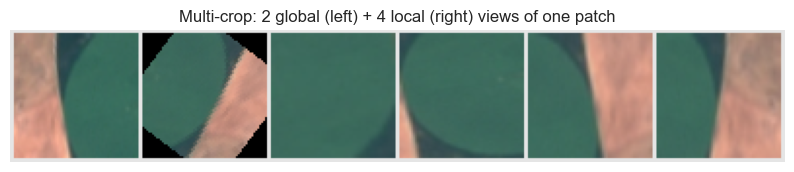

In [4]:
full_dataset = load_eurosat(DATASET_PATH, transform=multicrop)
train_idx, test_idx = stratified_split(full_dataset, test_size=0.2, seed=42)
train_subset = data.Subset(full_dataset, train_idx)
train_loader = data.DataLoader(train_subset, batch_size=64, shuffle=True, drop_last=True, num_workers=0, pin_memory=True)
print(f"DINO training pool: {len(train_subset)} images (labels discarded)")

# Visualize one image's 2 global + 4 local crops
sample_crops = full_dataset[train_idx[0]][0]
disp_crops = torch.stack([denormalize(c, EUROSAT_MEAN, EUROSAT_STD) for c in sample_crops])
show_image_grid(disp_crops, nrow=6, title="Multi-crop: 2 global (left) + 4 local (right) views of one patch")

## Model: student/teacher with a DINO head

Both student and teacher share the ViT-S/8 architecture, plus a small MLP projection head
(the "DINO head") that outputs a distribution over `out_dim` prototypes. There is no
explicit notion of "class" here, `out_dim` is just a large number of dimensions
(e.g. 1024) the network is free to use as it likes.

In [5]:
class DINOHead(nn.Module):
    def __init__(self, embed_dim=384, hidden_dim=512, out_dim=1024):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class DINOModel(nn.Module):
    def __init__(self, encoder, embed_dim=384, hidden_dim=512, out_dim=1024):
        super().__init__()
        self.encoder = encoder
        self.head = DINOHead(embed_dim, hidden_dim, out_dim)

    def forward(self, x):
        h = self.encoder.forward_features(x)
        return self.head(h)


student = DINOModel(build_vit_s8()).to(device)
teacher = deepcopy(student).to(device)
for p in teacher.parameters():
    p.requires_grad = False

out_dim = student.head.mlp[-1].out_features
center = torch.zeros(1, out_dim, device=device)

## EMA teacher update

The teacher is never trained by gradient descent. After each optimizer step on the student,
the teacher is updated as an exponential moving average of the student's weights:

$$
\theta_{\text{teacher}} \leftarrow m \, \theta_{\text{teacher}} + (1-m) \, \theta_{\text{student}}
$$

with momentum $m$ close to 1 (e.g. 0.996), so the teacher changes slowly and provides a
stable target for the fast-moving student.

In [6]:
@torch.no_grad()
def ema_update(student, teacher, m):
    '''In-place EMA update: teacher_param <- m * teacher_param + (1-m) * student_param.'''
    # --- SOLUTION START (ema_update) ---
    for student_param, teacher_param in zip(student.parameters(), teacher.parameters()):
        teacher_param.data.mul_(m).add_(student_param.data, alpha=1 - m)
    # --- SOLUTION END ---


# Quick sanity check: after one EMA step with m=0, teacher should exactly equal student
_s = nn.Linear(4, 4)
_t = nn.Linear(4, 4)
ema_update(_s, _t, m=0.0)
print("m=0 -> teacher matches student:", torch.allclose(_s.weight, _t.weight))
_s2 = nn.Linear(4, 4)
_t2 = deepcopy(_s2)
old_t2_weight = _t2.weight.clone()
with torch.no_grad():
    _s2.weight += 1.0
ema_update(_s2, _t2, m=1.0)
print("m=1 -> teacher unchanged:", torch.allclose(_t2.weight, old_t2_weight))

m=0 -> teacher matches student: True
m=1 -> teacher unchanged: True


## The DINO loss

The cell below computes the DINO objective for one (student view, teacher view) pair:

1. **Teacher**: its logits are centered (the running `center` is subtracted), sharpened with
   a **low** temperature `tau_teacher` (e.g. 0.04), then softmaxed and **detached**
   (stop-gradient; the teacher never receives gradients from this loss).
2. **Student**: its logits are sharpened with a **higher** temperature `tau_student`
   (e.g. 0.1), then log-softmaxed.
3. The loss is the cross-entropy between them: $-\sum_k p^{\text{teacher}}_k \log
   p^{\text{student}}_k$, averaged over all valid (student view, teacher view) pairs where
   the views come from different crops (pairing a view with itself is skipped).

In [7]:
def dino_loss(student_logits_list, teacher_logits_list, center, tau_student=0.1, tau_teacher=0.04):
    '''
    student_logits_list: list of (B, out_dim) tensors, one per student view (all crops)
    teacher_logits_list: list of (B, out_dim) tensors, one per teacher view (global crops only)
    center: (1, out_dim) running center of teacher outputs
    '''
    # --- SOLUTION START (dino_loss) ---
    student_log_probs = [F.log_softmax(s / tau_student, dim=-1) for s in student_logits_list]
    teacher_probs = [F.softmax((t - center) / tau_teacher, dim=-1).detach() for t in teacher_logits_list]

    total_loss = 0.0
    n_terms = 0
    for t_idx, t_probs in enumerate(teacher_probs):
        for s_idx, s_log_probs in enumerate(student_log_probs):
            if s_idx == t_idx:  # skip pairing a view with itself
                continue
            total_loss += -(t_probs * s_log_probs).sum(dim=-1).mean()
            n_terms += 1
    total_loss = total_loss / n_terms
    # --- SOLUTION END ---
    return total_loss


@torch.no_grad()
def update_center(center, teacher_logits_list, momentum=0.9):
    '''EMA update of the center over all teacher outputs in this batch.'''
    batch_center = torch.cat(teacher_logits_list, dim=0).mean(dim=0, keepdim=True)
    return center * momentum + batch_center * (1 - momentum)

## Live training on EuroSAT (dynamics only)

<div class="alert alert-info">

As in Notebooks 1-2, the student and teacher start from **random initialization** and this
short loop lets you watch the DINO dynamics, specifically the **entropy of the teacher's
output distribution**, our diagnostic for collapse (see discussion below). It does not produce
a strong encoder. The checkpoint loaded afterward used the same mechanism and the same random
start, but ran for 20,000 steps on the large Sentinel-2 corpus. We save the teacher's weights
from this cell so both encoders remain available for Notebook 4.

</div>


100%|██████████| 400/400 [03:58<00:00,  1.68it/s]


Saved this notebook's encoder to ../../artifacts/remote_sensing/checkpoints\dino_vit_s8_notebook.pt


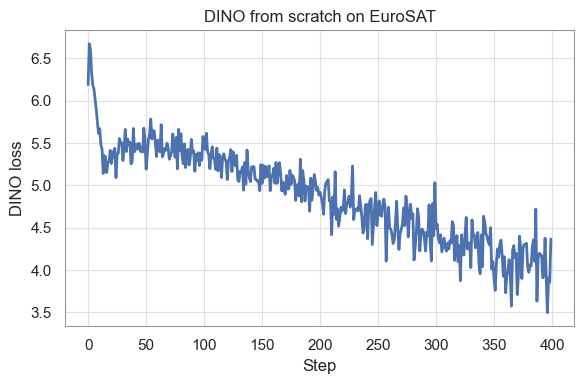

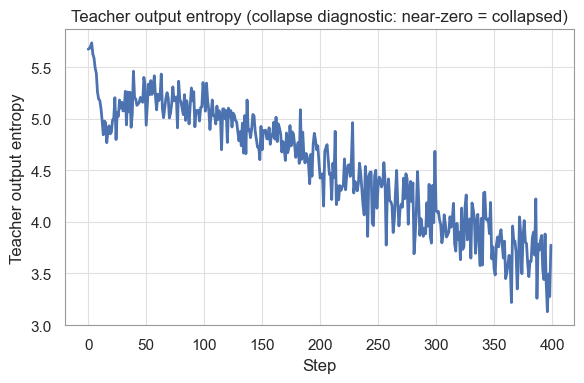

In [8]:
# 400 steps rather than ~100, matching Notebooks 1-2: from a random start the encoder needs
# noticeably more updates before anything but collapse dynamics is visible.
NUM_STEPS = 400
EMA_MOMENTUM = 0.996
CENTER_MOMENTUM = 0.9
TAU_STUDENT = 0.1
TAU_TEACHER = 0.04

optimizer = optim.AdamW(student.parameters(), lr=5e-4, weight_decay=1e-4)

loss_history, entropy_history = [], []
data_iter = iter(train_loader)
student.train()
teacher.eval()

for step in tqdm(range(NUM_STEPS)):
    try:
        crops, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        crops, _ = next(data_iter)
    crops = [c.to(device) for c in crops]  # list of (B, C, H, W), len = n_global + n_local

    student_logits = [student(c) for c in crops]
    with torch.no_grad():
        teacher_logits = [teacher(c) for c in crops[:2]]  # teacher only sees global crops

    loss = dino_loss(student_logits, teacher_logits, center, TAU_STUDENT, TAU_TEACHER)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ema_update(student, teacher, m=EMA_MOMENTUM)
    center = update_center(center, teacher_logits, momentum=CENTER_MOMENTUM)

    with torch.no_grad():
        teacher_probs = F.softmax((teacher_logits[0] - center) / TAU_TEACHER, dim=-1)
        entropy = -(teacher_probs * teacher_probs.clamp_min(1e-8).log()).sum(dim=-1).mean()

    loss_history.append(loss.item())
    entropy_history.append(entropy.item())

# Keep the teacher's weights: the teacher is the EMA of the student and is the encoder DINO
# actually exports for downstream use. Notebook 4 loads this file alongside the offline one.
NOTEBOOK_CKPT = os.path.join(CHECKPOINT_PATH, "dino_vit_s8_notebook.pt")
torch.save(teacher.encoder.state_dict(), NOTEBOOK_CKPT)
print(f"Saved this notebook's encoder to {NOTEBOOK_CKPT}")

plot_curve(loss_history, xlabel="Step", ylabel="DINO loss", title="DINO from scratch on EuroSAT")
plot_curve(entropy_history, xlabel="Step", ylabel="Teacher output entropy",
           title="Teacher output entropy (collapse diagnostic: near-zero = collapsed)")

<div class="alert alert-info">

**Optional experiment.** Try re-running the training loop above with `CENTER_MOMENTUM` set
so high that `center` barely updates (e.g. re-initialize `center` to zero and never call
`update_center`), i.e. effectively removing centering. You should see the teacher output
entropy collapse toward zero much faster. The model finds the trivial shortcut of mapping
every input to the same output, since without centering nothing stops it.

</div>

## Loading the pretrained encoder

In [9]:
pretrained_dino = DINOModel(build_vit_s8()).to(device)
found = try_load_checkpoint(pretrained_dino.encoder, CHECKPOINT_PATH, "dino_vit_s8.pt", device)
if not found:
    print("Falling back to the briefly-trained teacher from the live-training cell above.")
    pretrained_dino = teacher

pretrained_dino.eval()

Found pretrained model at ../../artifacts/remote_sensing/checkpoints\dino_vit_s8.pt, loading...


DINOModel(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
    )
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  )
  (head): DINOHead(
    (mlp): Sequential(
      (0): Linear(in_features=384, out_features=512, bias=True)
      (1): GELU(ap

## The DINO signature visual: self-attention maps

A well-known property of DINO is that the `[CLS]` token's self-attention, at the last block,
tends to highlight semantically meaningful regions without ever being trained for
segmentation. We take the attention from `[CLS]` to all patch tokens, averaged over heads,
and reshape it back to the 8x8 spatial grid to overlay on the original image.

Two details matter for making this readable, and both are handled by `show_attention_grid`:

- **Contrast.** `[CLS]` attention is heavy-tailed: one or two patches take most of the mass.
  Normalizing by plain min-max therefore pins everything else near zero and the overlay reads
  as a flat dark wash. We stretch between the 5th and 85th percentiles instead. This is a
  contrast stretch, not a rank normalization, so a genuinely uniform map still looks uniform.
- **Row of images above, row of overlays below**, sharing one colorbar, so the attention can
  actually be compared against what is in the scene rather than guessed at.

One sanity check worth knowing about: the patch-to-grid mapping is verified causally. If you
plant a bright square in patch `(r, c)` of a blank image, the attention argmax lands on
exactly `(r, c)`, for every position tested. So bright regions below really do correspond to
the image regions underneath them.

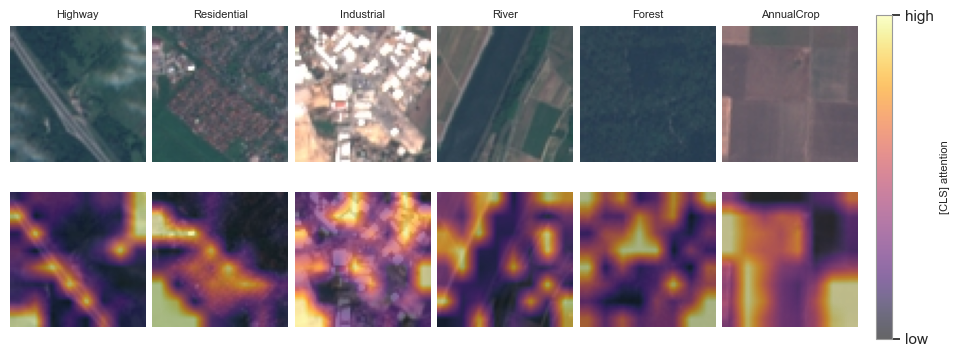

In [10]:
eval_transform = build_eval_transform(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
eval_dataset = load_eurosat(DATASET_PATH, transform=eval_transform)

encoder = pretrained_dino.encoder

# One image per class, drawn from the test split. EuroSAT is stored class by class and
# test_idx is sorted, so `test_idx[:6]` would return six images of the *same* class. We mix
# structured classes (Highway, Residential, Industrial, River) with homogeneous ones (Forest,
# AnnualCrop) on purpose: the contrast between them is what the figure is meant to show.
SHOWCASE = ["Highway", "Residential", "Industrial", "River", "Forest", "AnnualCrop"]
wanted = {EUROSAT_CLASSES.index(name) for name in SHOWCASE}

picked = {}
for idx in test_idx:
    label = int(eval_dataset.targets[idx])
    if label in wanted and label not in picked:
        picked[label] = idx
    if len(picked) == len(wanted):
        break

images, attn_maps, titles = [], [], []
for name in SHOWCASE:
    img, label = eval_dataset[picked[EUROSAT_CLASSES.index(name)]]
    # head="mean" averages the six heads. Try head="sharpest" for the single most spatially
    # selective head: the heads specialize a lot, so the mean is the representative summary
    # while "sharpest" shows how tightly one head can localize.
    attn_maps.append(cls_attention_map(encoder, img, head="mean", device=device))
    images.append(denormalize(img, EUROSAT_MEAN, EUROSAT_STD))
    titles.append(EUROSAT_CLASSES[label])

show_attention_grid(images, attn_maps, titles=titles, upsample_to=IMG_SIZE)

**Reading the attention maps.** High attention (bright regions) lands on distinctive
land-cover structure: the road running diagonally across *Highway*, the built cluster in
*Residential* (dark over the adjacent field), roofs in *Industrial*, the bank and field
boundaries in *River* and *AnnualCrop*. This emerges purely from the self-distillation
objective. Nothing in the DINO loss explicitly asks for localization, yet the `[CLS]` token
has to summarize "what makes this view match the other views of the same scene," which in
practice is the salient structure in the patch.

### References

- Caron, M., Touvron, H., Misra, I., Jegou, H., Mairal, J., Bojanowski, P., & Joulin, A.
  (2021). *Emerging Properties in Self-Supervised Vision Transformers (DINO).* ICCV.
- Oquab, M. et al. (2023). *DINOv2: Learning Robust Visual Features without Supervision.*
  arXiv:2304.07193.
- Assran, M. et al. (2023). *Self-Supervised Learning from Images with a Joint-Embedding
  Predictive Architecture (I-JEPA).* CVPR.